# Lab 4e
## Classification of three animals (from scratch)
#### In this example, we are going to train a CNN model from scratch for the classfication of three animals

In [1]:
# Initialization
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
!pip install gdown
!cd /content/
!gdown 1hO_sRQwh4MxqBXEuwGe-2KVIQr7OaE8g -O three_animals_dataset.zip
!unzip /content/three_animals_dataset.zip > /dev/null && echo "A total of $(find /content/three_animals_dataset/ -type f | wc -l) files have been successfully extracted."

Downloading...
From (original): https://drive.google.com/uc?id=1hO_sRQwh4MxqBXEuwGe-2KVIQr7OaE8g
From (redirected): https://drive.google.com/uc?id=1hO_sRQwh4MxqBXEuwGe-2KVIQr7OaE8g&confirm=t&uuid=3223e9fd-c8e2-4034-8ee6-d4479db40919
To: /content/three_animals_dataset.zip
100% 45.0M/45.0M [00:00<00:00, 58.3MB/s]
A total of 3000 files have been successfully extracted.


In [3]:
# Load modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Setup training images and testing images
train_dir = 'three_animals_dataset/train'
test_dir = 'three_animals_dataset/test/'

train_datagen = ImageDataGenerator(
                    rescale=1/255.,
                    validation_split=0.1,
                    rotation_range=30,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    shear_range=0.2,
                    zoom_range=0.2,
                    horizontal_flip=True,
                    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1/255.)

train_generator = train_datagen.flow_from_directory(
                    train_dir,
                    batch_size=32,
                    target_size=(150,150),
                    class_mode='categorical',
                    subset='training',
                    interpolation='bicubic'
)

validate_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    interpolation='bicubic'
)

test_generator = test_datagen.flow_from_directory(
                    test_dir,
                    batch_size=32,
                    target_size=(150,150),
                    class_mode='categorical',
                    shuffle=False)

Found 2430 images belonging to 3 classes.
Found 270 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


In [4]:
# Construct CNN
model = Sequential()
model.add(Conv2D(6, (5, 5), padding='same', activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Conv2D(16, (5, 5), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Flatten())
model.add(Dense(120, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.summary()

# Compile and train model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

history = model.fit(train_generator,
                    epochs=5,
                    validation_data=validate_generator,
                    verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 71, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     2,352,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,411 (9.02 MB)

 Trainable params: 2,365,411 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 42s 352ms/step - acc: 0.5276 - loss: 0.9970 - val_acc: 0.5444 - val_loss: 0.9258
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - acc: 0.6185 - loss: 0.8128 - val_acc: 0.6667 - val_loss: 0.7763
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - acc: 0.6691 - loss: 0.7486 - val_acc: 0.6444 - val_loss: 0.7786
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - acc: 0.6720 - loss: 0.7264 - val_acc: 0.6370 - val_loss: 0.7985
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 274ms/step - acc: 0.7008 - loss: 0.6896 - val_acc: 0.7185 - val_loss: 0.7182


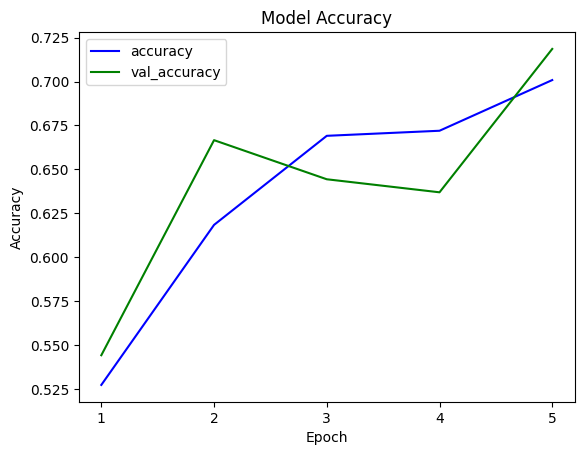

In [5]:
# Plot model accuracy and lose
acc = history.history['acc']
loss = history.history['loss']
val_acc = history.history['val_acc']
val_loss = history.history['val_loss']

plt.plot(np.arange(1, len(acc) + 1), acc, 'b', label='accuracy')
plt.plot(np.arange(1, len(val_acc) + 1), val_acc, 'g', label='val_accuracy')
plt.xlabel('Epoch')
plt.xticks(np.arange(1, len(acc) + 1))
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend(loc=0)
plt.show()

In [6]:
# Evaluate the performance of the trained model using the test set
score = model.evaluate(test_generator)
print(f'Loss: {score[0]:.4f}, accuracy: {score[1]:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - acc: 0.7733 - loss: 0.5624
Loss: 0.5624, accuracy: 0.7733


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


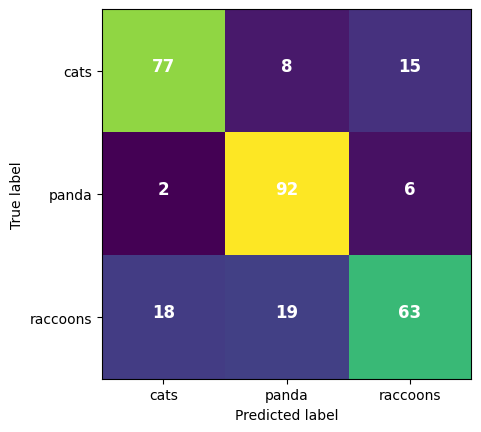

In [7]:
# Show the confusion matrix
pred = model.predict(test_generator)
y_pred = np.argmax(pred, axis=1)
cm = confusion_matrix(test_generator.classes, y_pred)
plt.style.use('default')
fig = plt.figure()
ax = plt.gca()
im = ax.matshow(cm)
for i, j in enumerate(cm.ravel()):
    ax.text(i%3, i//3, f'{j}', color='w', size='large', weight='bold', ha='center')
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(np.arange(3))
ax.set_xticklabels(list(train_generator.class_indices))
ax.set_yticks(np.arange(3))
ax.set_yticklabels(list(train_generator.class_indices))
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.show()

In [8]:
# serialize model to JSON
model_json = model.to_json()
with open("model1.json", "w") as json_file:
  json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("model1.weights.h5")
print("Saved model to disk")

from json import dump
with open('class_indices1.json', 'w') as f:
  dump(train_generator.class_indices, f)

Saved model to disk


In [9]:
# Test the trained model on a new image
from tensorflow.keras.models import model_from_json
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from json import load
import numpy as np

# load json and create model
json_file = open('model1.json', 'r')
model_json = json_file.read()
json_file.close()
model = model_from_json(model_json)
# load weights into new model
model.load_weights("model1.weights.h5")

# load class indices
with open('class_indices1.json', 'r') as f:
    class_indices = load(f)
print("Model loaded from disk")
map2class = {class_indices[k]:k for k in class_indices}

Model loaded from disk


In [ ]:
# Select new images and show the predicted class
from google.colab import files
uploaded = files.upload()

if not uploaded:
  print("No image uploaded. Exiting.")
else:
  for fn in uploaded.keys():
    image_path = fn
    img = load_img(image_path, target_size=(150, 150))
    x = img_to_array(img)/255.
    x = np.expand_dims(x, axis=0)
    classes = model.predict(x)

    predicted_class = "None"
    max_prob = 0.0

    for i, k in enumerate(class_indices):
      prob = classes[0, i]
      print(f'{k:10}: {prob: .3f}')
      if prob > 0.5 and prob > max_prob:
        max_prob = prob
        predicted_class = map2class[i]

    plt.axis(False)
    plt.imshow(load_img(image_path))
    plt.title(f'Predicted as {predicted_class}', y=0, pad=-10, verticalalignment="top")
    plt.show()

## Classification of three animals (with transfer learning)
#### In this example, we are going to train a CNN model with transfer learning for the classfication of three animals

In [10]:
# Load modules
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import Model
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Setup training images and testing images
train_dir = 'three_animals_dataset/train'
test_dir = 'three_animals_dataset/test/'

train_datagen = ImageDataGenerator(
                    rescale=1/255.,
                    validation_split=0.1,
                    rotation_range=30,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    shear_range=0.2,
                    zoom_range=0.2,
                    horizontal_flip=True,
                    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1/255.)

train_generator = train_datagen.flow_from_directory(
                    train_dir,
                    batch_size=32,
                    target_size=(150,150),
                    class_mode='categorical',
                    subset='training',
                    interpolation='bicubic'
)

validate_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    interpolation='bicubic'
)

test_generator = test_datagen.flow_from_directory(
                    test_dir,
                    batch_size=32,
                    target_size=(150,150),
                    class_mode='categorical',
                    shuffle=False)

Found 2430 images belonging to 3 classes.
Found 270 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


In [11]:
# Import the inception model, do not include the fully-connected layer at the top as the last layer of the network
base_model = InceptionV3(input_shape=(150, 150, 3), include_top=False, weights='imagenet')

# Make all the layers in the pre-trained model non-trainable
for layer in base_model.layers:
    layer.trainable = False

last_layer = base_model.get_layer('mixed7')
last_output = last_layer.output

# Applies average pooling on the spatial dimensions until each spatial dimension is one
x = GlobalAveragePooling2D()(last_output)
# Add a fully connected layer with 1024 hidden units and ReLU activation
x = Dense(512, activation='relu')(x)
# Add a dropout rate of 0.2
x = Dropout(0.2)(x)
# Add a final sigmoid layer for classification
x = Dense(3, activation='softmax')(x)

model = Model(base_model.input, x)

model.compile(optimizer ='rmsprop',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])

# Calculate the number of layers
num_layers = len(model.layers)

# Calculate the total number of parameters
total_params = model.count_params()

print(f'Number of layers: {num_layers}')
print(f'Total parameters to learn: {total_params}')

history = model.fit(train_generator,
                    epochs=3,
                    validation_data=validate_generator,
                    verbose=1)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers: 233
Total parameters to learn: 9370531
Epoch 1/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 47s 465ms/step - acc: 0.8531 - loss: 0.3674 - val_acc: 0.9037 - val_loss: 0.2405
Epoch 2/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 285ms/step - acc: 0.9346 - loss: 0.1756 - val_acc: 0.8667 - val_loss: 0.3220
Epoch 3/3
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 276ms/step - acc: 0.9436 - loss: 0.1488 - val_acc: 0.9407 - val_loss: 0.1660


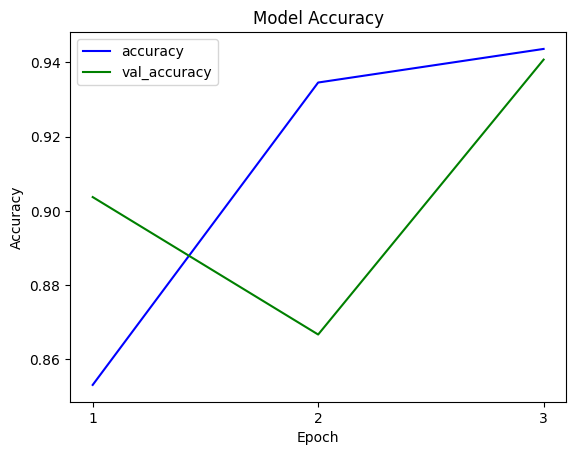

In [12]:
# Plot model accuracy and lose
acc = history.history['acc']
loss = history.history['loss']
val_acc = history.history['val_acc']
val_loss = history.history['val_loss']

plt.plot(np.arange(1, len(acc) + 1), acc, 'b', label='accuracy')
plt.plot(np.arange(1, len(val_acc) + 1), val_acc, 'g', label='val_accuracy')
plt.xlabel('Epoch')
plt.xticks(np.arange(1, len(acc) + 1))
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend(loc=0)
plt.show()

In [13]:
# Evaluate the performance of the trained model using the test set
score = model.evaluate(test_generator)
print(f'Loss: {score[0]:.4f}, accuracy: {score[1]:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 463ms/step - acc: 0.9767 - loss: 0.0879
Loss: 0.0879, accuracy: 0.9767


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 565ms/step


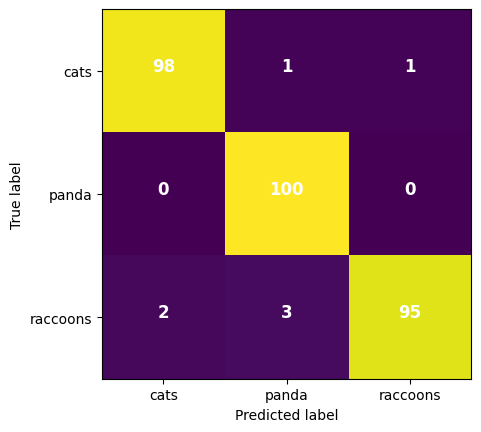

In [14]:
# Show the confusion matrix
pred = model.predict(test_generator)
y_pred = np.argmax(pred, axis=1)
cm = confusion_matrix(test_generator.classes, y_pred)
plt.style.use('default')
fig = plt.figure()
ax = plt.gca()
im = ax.matshow(cm)
for i, j in enumerate(cm.ravel()):
    ax.text(i%3, i//3, f'{j}', color='w', size='large', weight='bold', ha='center')
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(np.arange(3))
ax.set_xticklabels(list(train_generator.class_indices))
ax.set_yticks(np.arange(3))
ax.set_yticklabels(list(train_generator.class_indices))
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.show()

In [15]:
# serialize model to JSON
model_json = model.to_json()
with open("model2.json", "w") as json_file:
  json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("model2.weights.h5")
print("Saved model to disk")

from json import dump
with open('class_indices2.json', 'w') as f:
  dump(train_generator.class_indices, f)

Saved model to disk


In [16]:
# Test the trained model on a new image
from tensorflow.keras.models import model_from_json
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from json import load
import numpy as np

# load json and create model
json_file = open('model2.json', 'r')
model_json = json_file.read()
json_file.close()
model = model_from_json(model_json)
# load weights into new model
model.load_weights("model2.weights.h5")

# load class indices
with open('class_indices2.json', 'r') as f:
    class_indices = load(f)
print("Model loaded from disk")
map2class = {class_indices[k]:k for k in class_indices}

Model loaded from disk


In [ ]:
# Select new images and show the predicted class
from google.colab import files
uploaded = files.upload()

if not uploaded:
  print("No image uploaded. Exiting.")
else:
  for fn in uploaded.keys():
    image_path = fn
    img = load_img(image_path, target_size=(150, 150))
    x = img_to_array(img)/255.
    x = np.expand_dims(x, axis=0)
    classes = model.predict(x)

    predicted_class = "None"
    max_prob = 0.0

    for i, k in enumerate(class_indices):
      prob = classes[0, i]
      print(f'{k:10}: {prob: .3f}')
      if prob > 0.5 and prob > max_prob:
        max_prob = prob
        predicted_class = map2class[i]

    plt.axis(False)
    plt.imshow(load_img(image_path))
    plt.title(f'Predicted as {predicted_class}', y=0, pad=-10, verticalalignment="top")
    plt.show()